<a href="https://www.kaggle.com/code/aamir28/why-do-employees-leave?scriptVersionId=342053918" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:linear-gradient(135deg,#1E1B4B 0%,#2D2A6E 100%); padding:44px 40px; border-radius:14px; border:1px solid #3D3A82; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:14px;">
    <div style="width:32px; height:32px; border-radius:8px; background:linear-gradient(135deg,#F5A623,#F76B6B); display:flex; align-items:center; justify-content:center; font-size:16px;">👥</div>
    <span style="font-size:12px; font-weight:700; color:#B8B4E8; letter-spacing:1.2px; text-transform:uppercase;">People Analytics — HR 2026</span>
  </div>

  <h1 style="margin:0 0 8px 0; font-size:34px; color:#FFFFFF; font-weight:800; letter-spacing:-0.5px;">
    Why Do Employees Leave?
  </h1>
  <p style="margin:0 0 28px 0; font-size:15px; color:#B8B4E8; max-width:640px;">
    5,000 employees across 8 departments — compensation, wellbeing, work mode, and AI-era anxieties, all against real attrition outcomes
  </p>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:14px;">
    <div style="background:rgba(255,255,255,0.06); border-radius:10px; padding:16px;">
      <div style="color:#F5A623; font-size:22px; font-weight:800;">5,000</div>
      <div style="font-size:11px; color:#B8B4E8; margin-top:2px;">employees</div>
    </div>
    <div style="background:rgba(255,255,255,0.06); border-radius:10px; padding:16px;">
      <div style="color:#F76B6B; font-size:22px; font-weight:800;">17.9%</div>
      <div style="font-size:11px; color:#B8B4E8; margin-top:2px;">attrition rate</div>
    </div>
    <div style="background:rgba(255,255,255,0.06); border-radius:10px; padding:16px;">
      <div style="color:#6BCB9E; font-size:22px; font-weight:800;">8</div>
      <div style="font-size:11px; color:#B8B4E8; margin-top:2px;">departments</div>
    </div>
    <div style="background:rgba(255,255,255,0.06); border-radius:10px; padding:16px;">
      <div style="color:#7FB8E0; font-size:22px; font-weight:800;">25</div>
      <div style="font-size:11px; color:#B8B4E8; margin-top:2px;">job roles</div>
    </div>
  </div>

  <p style="margin:22px 0 0 0; font-size:12.5px; color:#8B87C4;">
    Author: <b style="color:#FFFFFF;">Muhammad Aamir</b> &nbsp;|&nbsp; Target: <code>attrition</code> &nbsp;|&nbsp; Includes perceived AI job-risk — a distinctly 2026 HR signal
  </p>

</div>



<div style="background:#F5F5FA; border-left:4px solid #2D2A6E; border-radius:10px; padding:20px 26px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B;">
<h3 style="margin-top:0; font-weight:700; color:#2D2A6E; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#setup" style="color:#2D2A6E; text-decoration:none;">Setup &amp; Dashboard Styling</a></li>
<li><a href="#firstlook" style="color:#2D2A6E; text-decoration:none;">First Look at the Workforce</a></li>
<li><a href="#quality" style="color:#2D2A6E; text-decoration:none;">Data Quality Check</a></li>
<li><a href="#workforce" style="color:#2D2A6E; text-decoration:none;">Workforce Overview</a></li>
<li><a href="#comp" style="color:#2D2A6E; text-decoration:none;">Compensation &amp; Career Landscape</a></li>
<li><a href="#wellbeing" style="color:#2D2A6E; text-decoration:none;">Wellbeing Indicators</a></li>
<li><a href="#drivers" style="color:#2D2A6E; text-decoration:none;">What Actually Drives Attrition</a></li>
<li><a href="#dept" style="color:#2D2A6E; text-decoration:none;">Department &amp; Work Mode Patterns</a></li>
<li><a href="#ai" style="color:#2D2A6E; text-decoration:none;">The AI Angle</a></li>
<li><a href="#corr" style="color:#2D2A6E; text-decoration:none;">Correlation Check</a></li>
<li><a href="#dashboard" style="color:#2D2A6E; text-decoration:none;">People Analytics Dashboard</a></li>
<li><a href="#model" style="color:#2D2A6E; text-decoration:none;">Predicting Attrition</a></li>
<li><a href="#conclusion" style="color:#2D2A6E; text-decoration:none;">Closing Notes</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">⚙️ 1. Setup &amp; Dashboard Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "People Analytics" indigo & coral palette ----
BG        = '#F5F5FA'
PANEL     = '#FFFFFF'
INK       = '#1E1B4B'
INK_SOFT  = '#7A76A8'
INDIGO    = '#2D2A6E'
CORAL     = '#F76B6B'
AMBER     = '#F5A623'
GREEN     = '#6BCB9E'
BLUE      = '#7FB8E0'
GRID      = '#E4E3F0'

ATTR_COLORS = {'No': GREEN, 'Yes': CORAL}
WORKMODE_COLORS = {'Remote': GREEN, 'Hybrid': AMBER, 'Onsite': CORAL}
PALETTE_CAT = [INDIGO, CORAL, AMBER, GREEN, BLUE]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Dashboard styling loaded.")


Dashboard styling loaded.


<h2 id="firstlook" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">🗂️ 2. First Look at the Workforce</h2>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/uditjain13/employee-attrition-and-hr-analytics-2026/employee_attrition_hr_2026.csv')
print(f"Shape: {df.shape[0]:,} employees x {df.shape[1]} columns\n")
df.head(6)


Shape: 5,000 employees x 29 columns



,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,...,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
0,1001,37,Male,Divorced,Masters,Engineering,Engineering Manager,3,7365,0,...,17,9.4,1.0,9.7,7.7,3,8.3,True,4.8,No
1,1002,24,Female,Married,Bachelors,Finance,Finance Manager,2,4746,2,...,21,4.2,1.9,5.4,7.8,3,8.0,True,2.9,Yes
2,1003,24,Female,Single,Bachelors,Marketing,Marketing Specialist,1,2740,2,...,22,7.5,5.3,6.5,7.0,4,9.5,True,7.2,No
3,1004,44,Male,Single,Bachelors,Sales,Sales Manager,4,7334,1,...,21,8.7,4.3,7.3,3.5,4,7.9,False,5.2,No
4,1005,37,Female,Divorced,Bachelors,Sales,Sales Development Rep,3,9096,0,...,20,7.5,2.3,7.0,7.2,4,8.5,False,6.4,No
5,1006,25,Male,Married,Bachelors,Customer Support,Support Specialist,2,4052,1,...,13,6.8,4.5,8.2,7.0,4,7.9,True,7.3,No


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   employee_id                    5000 non-null   int64  
 1   age                            5000 non-null   int64  
 2   gender                         5000 non-null   object 
 3   marital_status                 5000 non-null   object 
 4   education_level                5000 non-null   object 
 5   department                     5000 non-null   object 
 6   job_role                       5000 non-null   object 
 7   job_level                      5000 non-null   int64  
 8   monthly_income                 5000 non-null   int64  
 9   stock_option_level             5000 non-null   int64  
 10  salary_hike_pct                5000 non-null   float64
 11  years_at_company               5000 non-null   float64
 12  total_working_years            5000 non-null   f

<h2 id="quality" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">🔍 3. Data Quality Check</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print("\nAttrition balance:")
print(df['attrition'].value_counts(normalize=True).round(3))
df['attr_bin'] = (df['attrition'] == 'Yes').astype(int)


Duplicate rows: 0
Missing values: 0

Attrition balance:
attrition
No     0.821
Yes    0.179
Name: proportion, dtype: float64



<div style="background:#F5F5FA; border-left:3px solid #6BCB9E; padding:14px 20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#333; font-size:14px; border-radius:8px;">
Clean dataset: no duplicates, no missing values. Attrition sits at 17.9% — a moderate imbalance we'll account for
with class weighting in the modeling section rather than ignoring it.
</div>


<h2 id="workforce" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">🏢 4. Workforce Overview</h2>

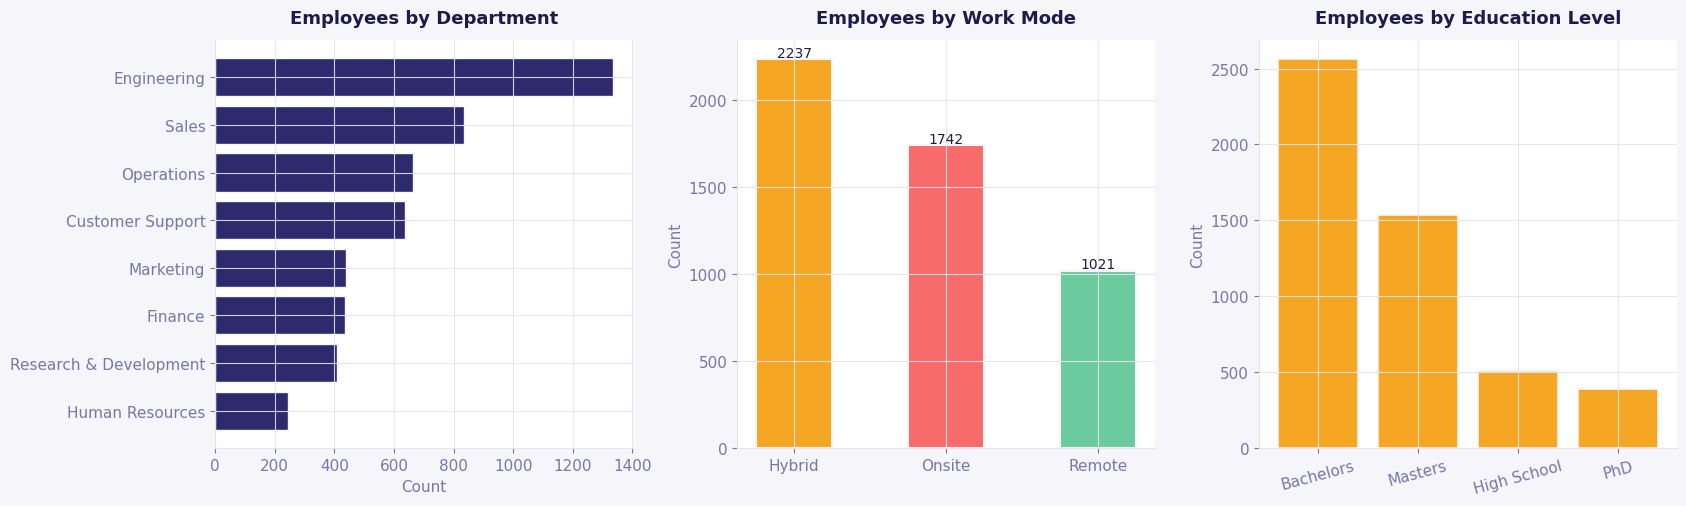

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
dept_counts = df['department'].value_counts()
bars = ax.barh(dept_counts.index[::-1], dept_counts.values[::-1], color=INDIGO, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Employees by Department', 'Count', '')

ax = axes[1]
mode_counts = df['work_mode'].value_counts()
bars = ax.bar(mode_counts.index, mode_counts.values, color=[WORKMODE_COLORS[m] for m in mode_counts.index], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15, int(b.get_height()), ha='center', fontsize=10, color=INK)
style_ax(ax, 'Employees by Work Mode', '', 'Count')

ax = axes[2]
edu_counts = df['education_level'].value_counts()
bars = ax.bar(edu_counts.index, edu_counts.values, color=AMBER, edgecolor=BG, linewidth=1.2)
style_ax(ax, 'Employees by Education Level', '', 'Count')
plt.setp(ax.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()


<h2 id="comp" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">💰 5. Compensation &amp; Career Landscape</h2>

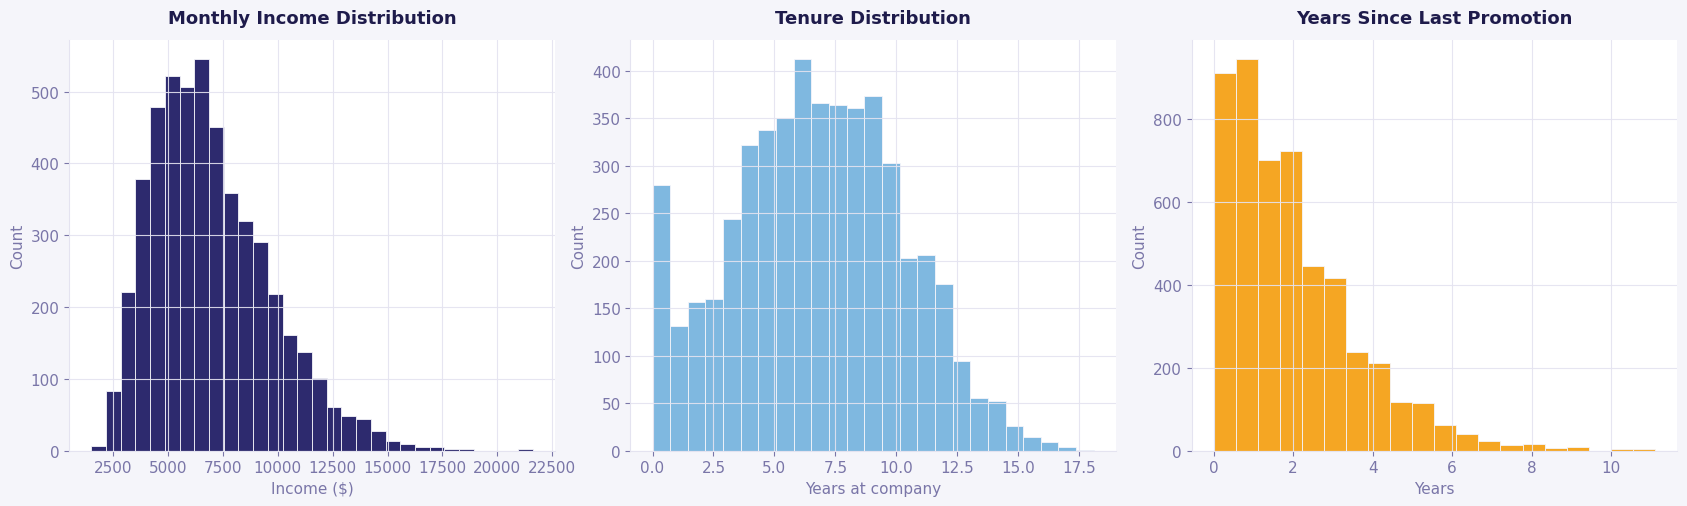

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
ax.hist(df['monthly_income'], bins=30, color=INDIGO, edgecolor=BG, linewidth=0.6)
style_ax(ax, 'Monthly Income Distribution', 'Income ($)', 'Count')

ax = axes[1]
ax.hist(df['years_at_company'], bins=25, color=BLUE, edgecolor=BG, linewidth=0.6)
style_ax(ax, 'Tenure Distribution', 'Years at company', 'Count')

ax = axes[2]
ax.hist(df['years_since_promotion'], bins=20, color=AMBER, edgecolor=BG, linewidth=0.6)
style_ax(ax, 'Years Since Last Promotion', 'Years', 'Count')

plt.tight_layout()
plt.show()


<h2 id="wellbeing" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">🧘 6. Wellbeing Indicators</h2>

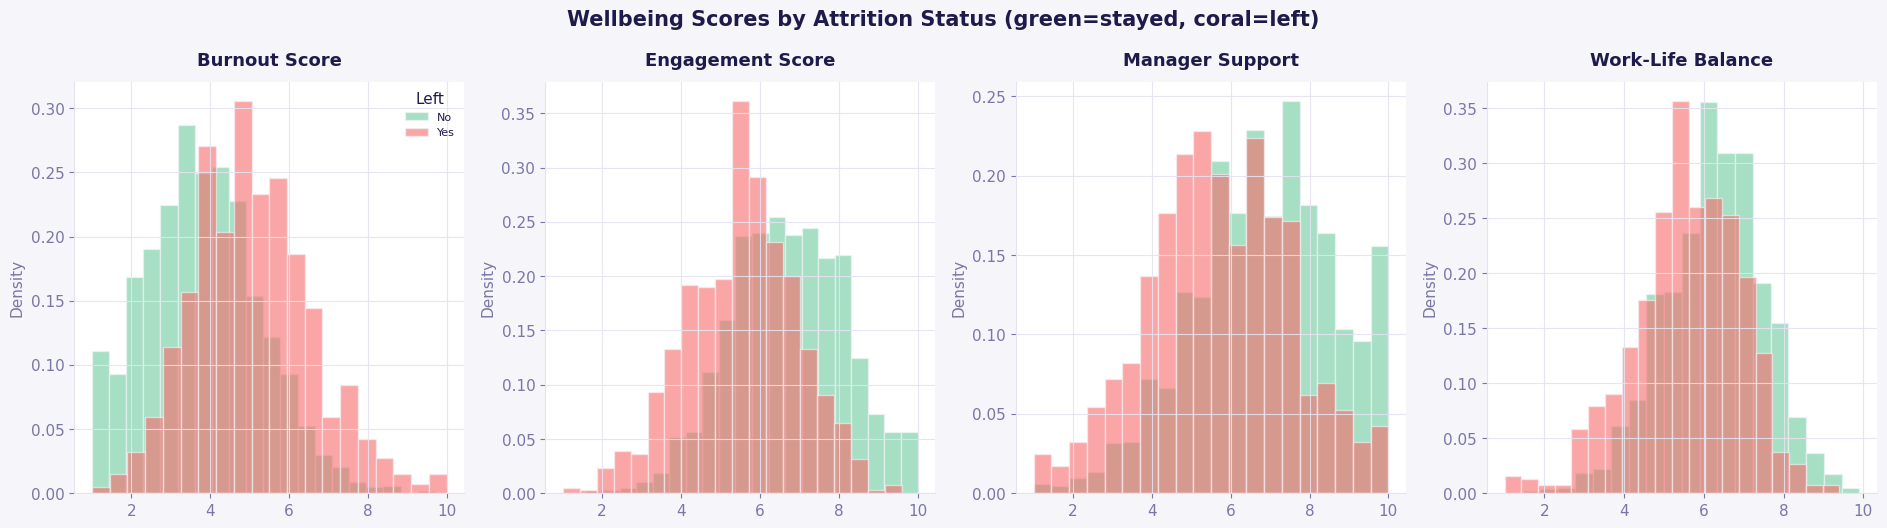

In [7]:

fig, axes = plt.subplots(1, 4, figsize=(19, 5))
wellbeing_fields = [('burnout_score', CORAL, 'Burnout Score'), ('engagement_score', GREEN, 'Engagement Score'),
                    ('manager_support_score', BLUE, 'Manager Support'), ('work_life_balance_score', AMBER, 'Work-Life Balance')]

for ax, (col, c, label) in zip(axes, wellbeing_fields):
    for status, sc in ATTR_COLORS.items():
        ax.hist(df[df.attrition==status][col], bins=20, alpha=0.6, color=sc, density=True, label=status, edgecolor=BG)
    style_ax(ax, label, '', 'Density')
    if col == 'burnout_score': ax.legend(frameon=False, fontsize=8, title='Left')

plt.tight_layout()
plt.suptitle('Wellbeing Scores by Attrition Status (green=stayed, coral=left)', y=1.05, fontsize=15, color=INK, fontweight='bold')
plt.show()


<h2 id="drivers" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">📈 7. What Actually Drives Attrition</h2>

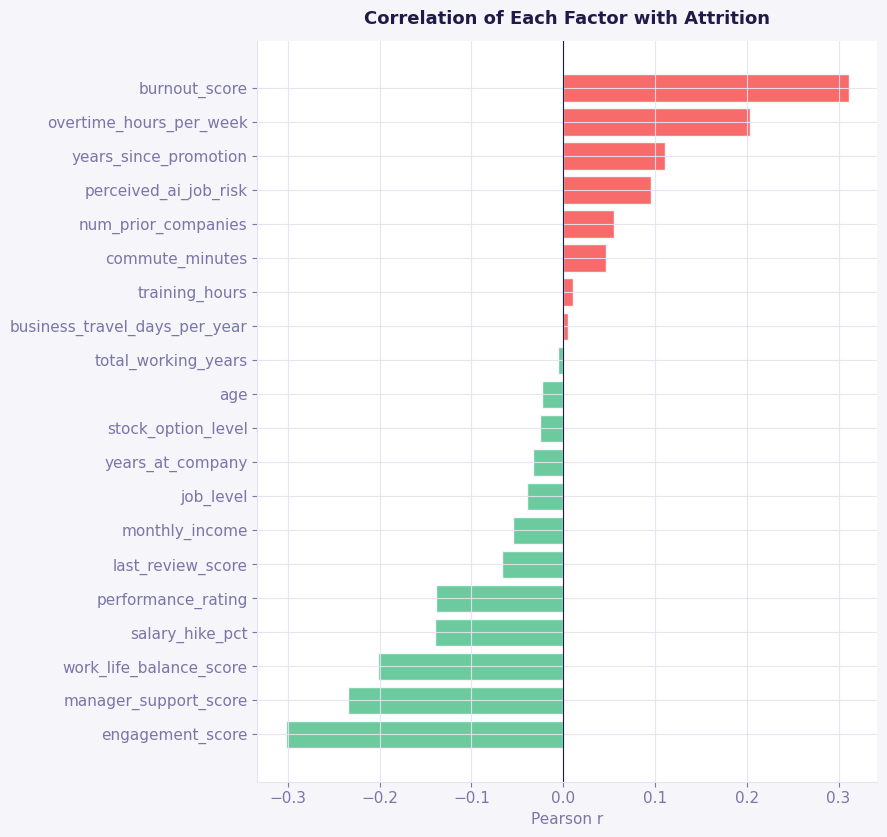

Burnout is the single strongest risk factor (r≈0.31), while engagement, manager support and work-life
balance are the strongest protective factors (all negatively correlated) — a coherent, believable
'employees leave because of how work feels, not just what it pays' story.


In [8]:

num_cols = ['age','job_level','monthly_income','stock_option_level','salary_hike_pct','years_at_company',
            'total_working_years','years_since_promotion','num_prior_companies','commute_minutes',
            'overtime_hours_per_week','business_travel_days_per_year','training_hours','manager_support_score',
            'burnout_score','engagement_score','work_life_balance_score','performance_rating','last_review_score',
            'perceived_ai_job_risk']
corrs = df[num_cols].corrwith(df['attr_bin']).sort_values()

fig, ax = plt.subplots(figsize=(9, 8.5))
colors = [GREEN if v<0 else CORAL for v in corrs.values]
bars = ax.barh(corrs.index, corrs.values, color=colors, edgecolor=BG, linewidth=1.0)
ax.axvline(0, color=INK, linewidth=0.8)
style_ax(ax, 'Correlation of Each Factor with Attrition', 'Pearson r', '')
plt.tight_layout()
plt.show()

print("Burnout is the single strongest risk factor (r≈0.31), while engagement, manager support and work-life")
print("balance are the strongest protective factors (all negatively correlated) — a coherent, believable")
print("'employees leave because of how work feels, not just what it pays' story.")


<h2 id="dept" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">🏬 8. Department &amp; Work Mode Patterns</h2>

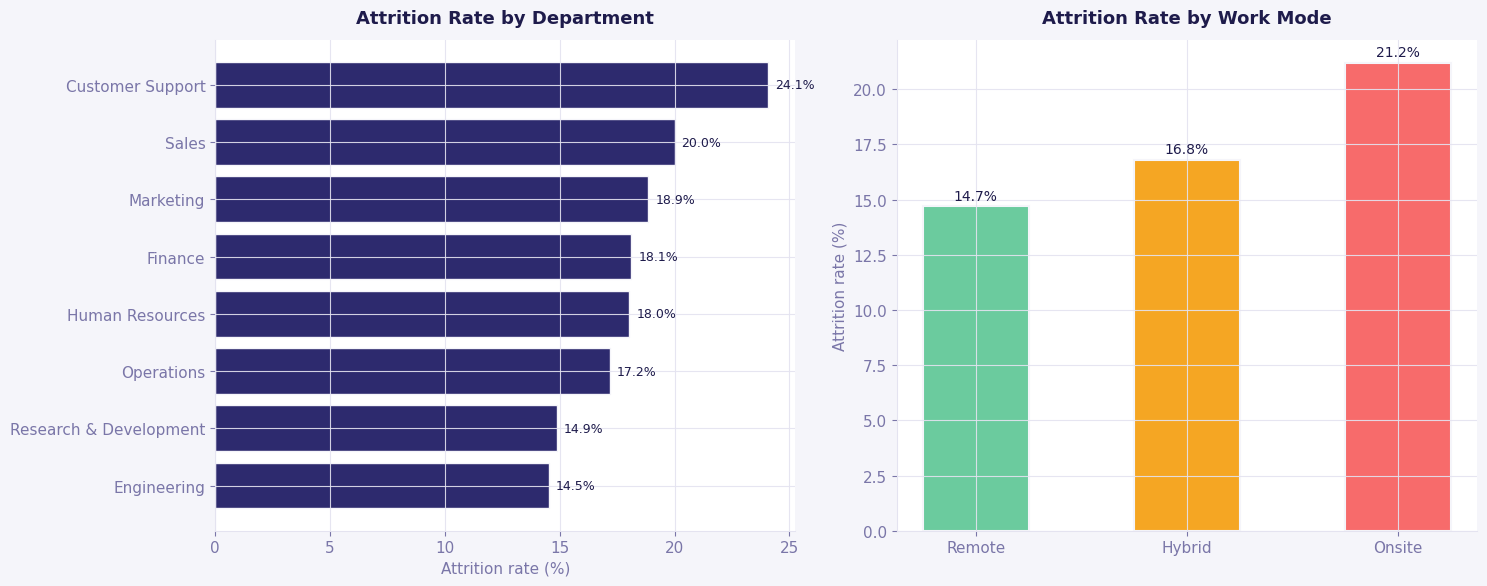

Customer Support shows the highest departmental attrition (24.1%), Engineering the
lowest (14.5%). Onsite work shows the highest attrition by work mode, Remote the lowest —
consistent with well-documented 2020s-era friction around return-to-office mandates.


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
dept_attr = df.groupby('department')['attr_bin'].mean().sort_values()*100
bars = ax.barh(dept_attr.index, dept_attr.values, color=INDIGO, edgecolor=BG, linewidth=1.0)
for b in bars:
    ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}%", va='center', fontsize=9, color=INK)
style_ax(ax, 'Attrition Rate by Department', 'Attrition rate (%)', '')

ax = axes[1]
mode_attr = df.groupby('work_mode')['attr_bin'].mean().sort_values()*100
bars = ax.bar(mode_attr.index, mode_attr.values, color=[WORKMODE_COLORS[m] for m in mode_attr.index], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.1f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Attrition Rate by Work Mode', '', 'Attrition rate (%)')

plt.tight_layout()
plt.show()

print(f"Customer Support shows the highest departmental attrition ({dept_attr.iloc[-1]:.1f}%), Engineering the")
print(f"lowest ({dept_attr.iloc[0]:.1f}%). Onsite work shows the highest attrition by work mode, Remote the lowest —")
print("consistent with well-documented 2020s-era friction around return-to-office mandates.")


<h2 id="ai" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">🤖 9. The AI Angle</h2>

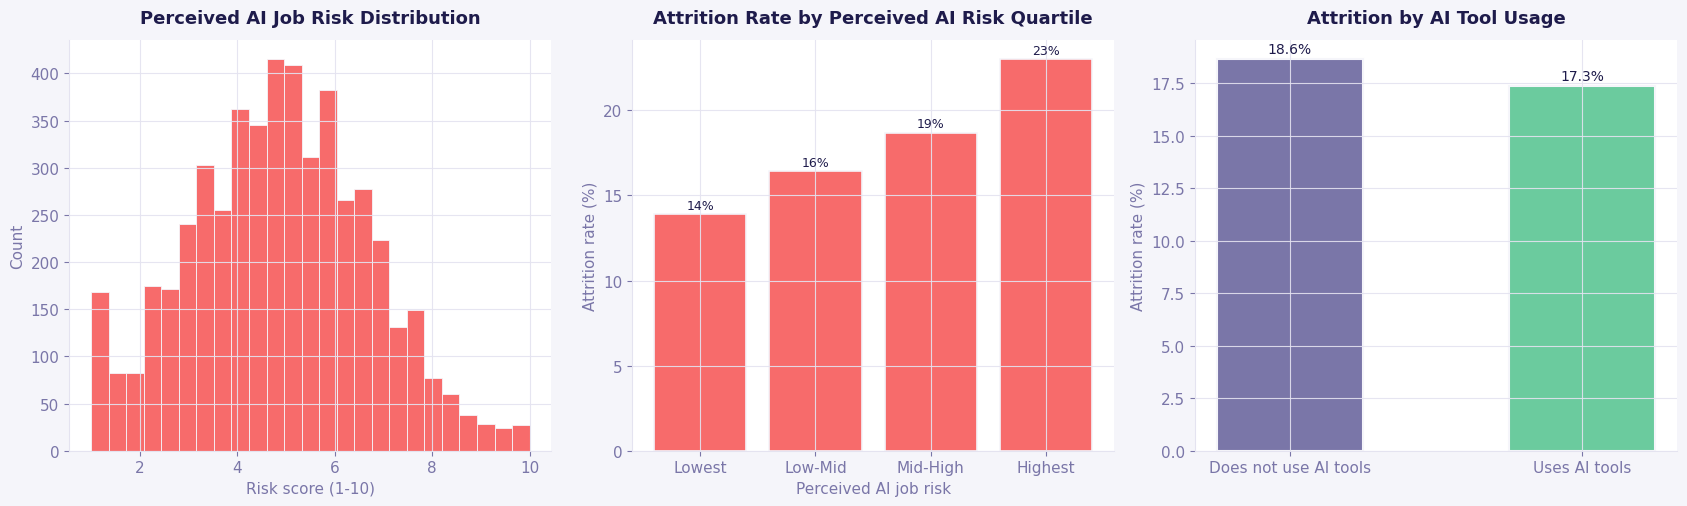

Employees who use AI tools at work perceive slightly *lower* job risk from AI (4.70) than
those who don't (5.07) — familiarity with the tools associates with less anxiety about them,
and AI tool users also show modestly lower attrition, though this is a correlation, not evidence that using AI tools reduces someone's chance of leaving.


In [10]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
ax.hist(df['perceived_ai_job_risk'], bins=25, color=CORAL, edgecolor=BG, linewidth=0.6)
style_ax(ax, 'Perceived AI Job Risk Distribution', 'Risk score (1-10)', 'Count')

ax = axes[1]
ai_bins = pd.qcut(df['perceived_ai_job_risk'], 4, labels=['Lowest','Low-Mid','Mid-High','Highest'])
ai_attr = df.groupby(ai_bins, observed=True)['attr_bin'].mean()*100
bars = ax.bar(ai_attr.index.astype(str), ai_attr.values, color=CORAL, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.0f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Attrition Rate by Perceived AI Risk Quartile', 'Perceived AI job risk', 'Attrition rate (%)')

ax = axes[2]
ai_use_attr = df.groupby('uses_ai_tools_at_work')['attr_bin'].mean()*100
bars = ax.bar(['Does not use AI tools', 'Uses AI tools'], ai_use_attr.values, color=[INK_SOFT, GREEN], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.1f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Attrition by AI Tool Usage', '', 'Attrition rate (%)')

plt.tight_layout()
plt.show()

ai_by_use = df.groupby('uses_ai_tools_at_work')['perceived_ai_job_risk'].mean()
print(f"Employees who use AI tools at work perceive slightly *lower* job risk from AI ({ai_by_use[True]:.2f}) than")
print(f"those who don't ({ai_by_use[False]:.2f}) — familiarity with the tools associates with less anxiety about them,")
print("and AI tool users also show modestly lower attrition, though this is a correlation, not evidence that using AI tools reduces someone's chance of leaving.")


<h2 id="corr" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">🔗 10. Correlation Check</h2>

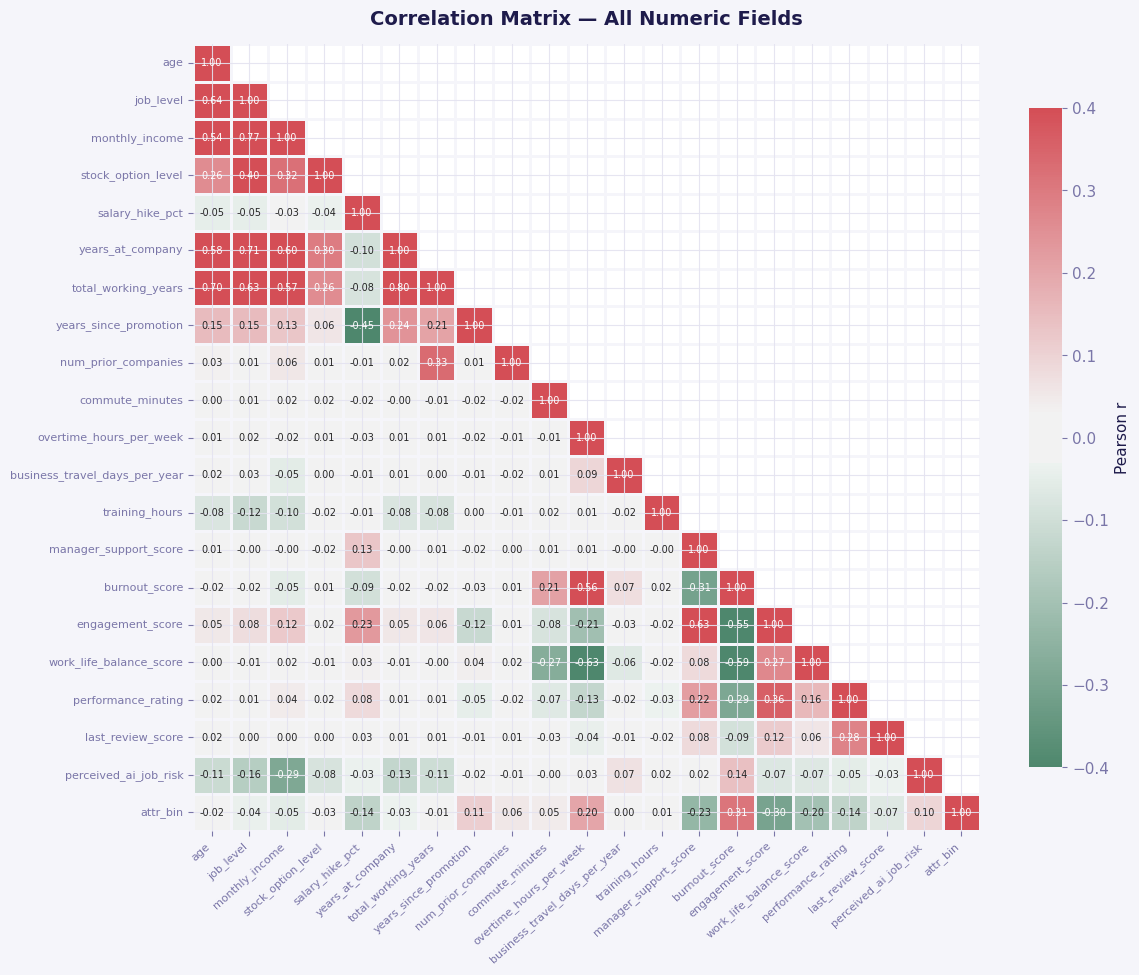

In [11]:

corr_cols = num_cols + ['attr_bin']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
cmap = sns.diverging_palette(150, 10, s=60, l=52, sep=20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-0.4, vmax=0.4,
            square=True, linewidths=1.0, linecolor=BG, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            annot_kws={'fontsize':7}, ax=ax)
ax.set_title('Correlation Matrix — All Numeric Fields', color=INK, pad=14)
plt.xticks(rotation=42, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


<h2 id="dashboard" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">📊 11. People Analytics Dashboard</h2>

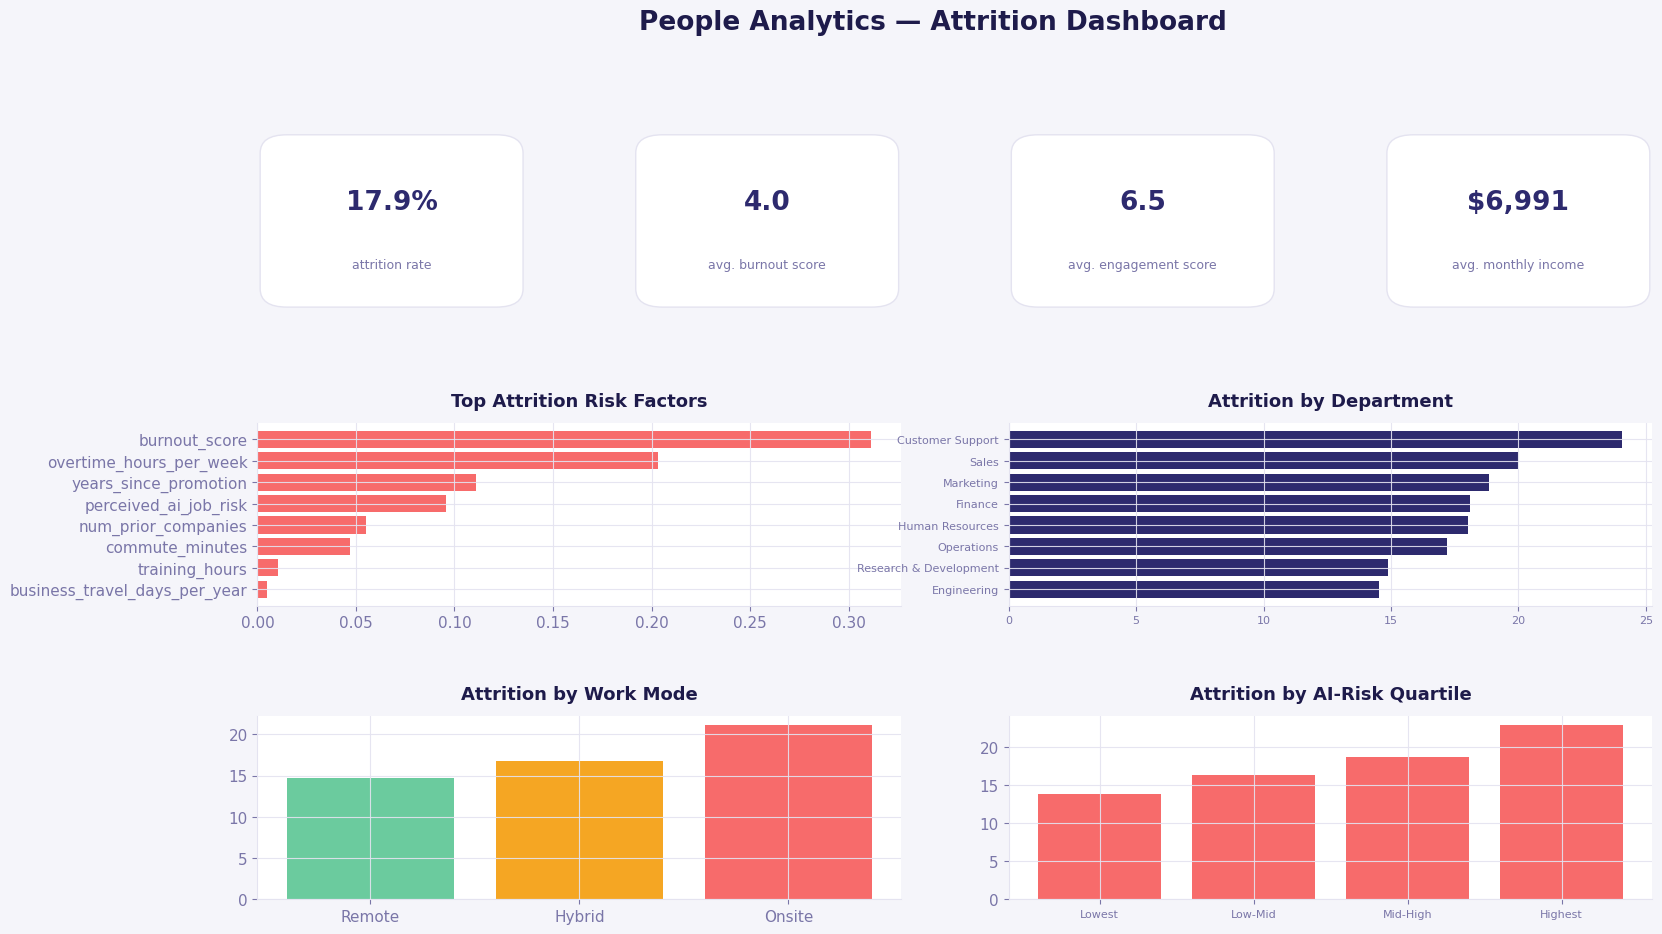

In [12]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('People Analytics — Attrition Dashboard', fontsize=19, color=INK, fontweight='bold', y=1.0)

stat_cells = [
    (f"{df['attr_bin'].mean()*100:.1f}%", "attrition rate"),
    (f"{df['burnout_score'].mean():.1f}", "avg. burnout score"),
    (f"{df['engagement_score'].mean():.1f}", "avg. engagement score"),
    (f"${df['monthly_income'].mean():,.0f}", "avg. monthly income"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.10",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    ax.text(0.5, 0.60, val, ha='center', va='center', fontsize=19, color=INDIGO, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.26, lab, ha='center', va='center', fontsize=9, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
bars = ax.barh(corrs.tail(8).index, corrs.tail(8).values, color=CORAL)
style_ax(ax, 'Top Attrition Risk Factors', '', '')

ax = fig.add_subplot(gs[1, 2:])
bars = ax.barh(dept_attr.index, dept_attr.values, color=INDIGO)
style_ax(ax, 'Attrition by Department', '', '')
ax.tick_params(labelsize=8)

ax = fig.add_subplot(gs[2, :2])
bars = ax.bar(mode_attr.index, mode_attr.values, color=[WORKMODE_COLORS[m] for m in mode_attr.index])
style_ax(ax, 'Attrition by Work Mode', '', '')

ax = fig.add_subplot(gs[2, 2:])
bars = ax.bar(ai_attr.index.astype(str), ai_attr.values, color=CORAL)
style_ax(ax, 'Attrition by AI-Risk Quartile', '', '')
plt.setp(ax.get_xticklabels(), fontsize=8)

plt.show()


<h2 id="model" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1E1B4B; border-bottom:3px solid #2D2A6E; padding-bottom:8px;">🤖 12. Predicting Attrition</h2>

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                              classification_report, confusion_matrix)

model_df = df.copy()
cat_cols = ['gender','marital_status','education_level','department','job_role','work_mode']
for c in cat_cols:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])
model_df['uses_ai_tools_at_work'] = model_df['uses_ai_tools_at_work'].astype(int)

features = ['age','gender','marital_status','education_level','department','job_role','job_level',
            'monthly_income','stock_option_level','salary_hike_pct','years_at_company','total_working_years',
            'years_since_promotion','num_prior_companies','work_mode','commute_minutes','overtime_hours_per_week',
            'business_travel_days_per_year','training_hours','manager_support_score','burnout_score',
            'engagement_score','work_life_balance_score','performance_rating','last_review_score',
            'uses_ai_tools_at_work','perceived_ai_job_risk']
X = model_df[features]
y = model_df['attr_bin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), X_train_s, X_test_s),
    'Random Forest': (RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1), X_train, X_test),
    'XGBoost': (XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42, eval_metric='logloss'), X_train, X_test)
}

results = {}
for name, (m, Xtr, Xte) in models.items():
    m.fit(Xtr, y_train)
    proba = m.predict_proba(Xte)[:,1]
    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    results[name] = {'model': m, 'proba': proba, 'auc': auc, 'ap': ap}
    print(f"{name}: ROC-AUC = {auc:.3f} | Average Precision = {ap:.3f}")


Logistic Regression: ROC-AUC = 0.804 | Average Precision = 0.510
Random Forest: ROC-AUC = 0.792 | Average Precision = 0.473
XGBoost: ROC-AUC = 0.743 | Average Precision = 0.432


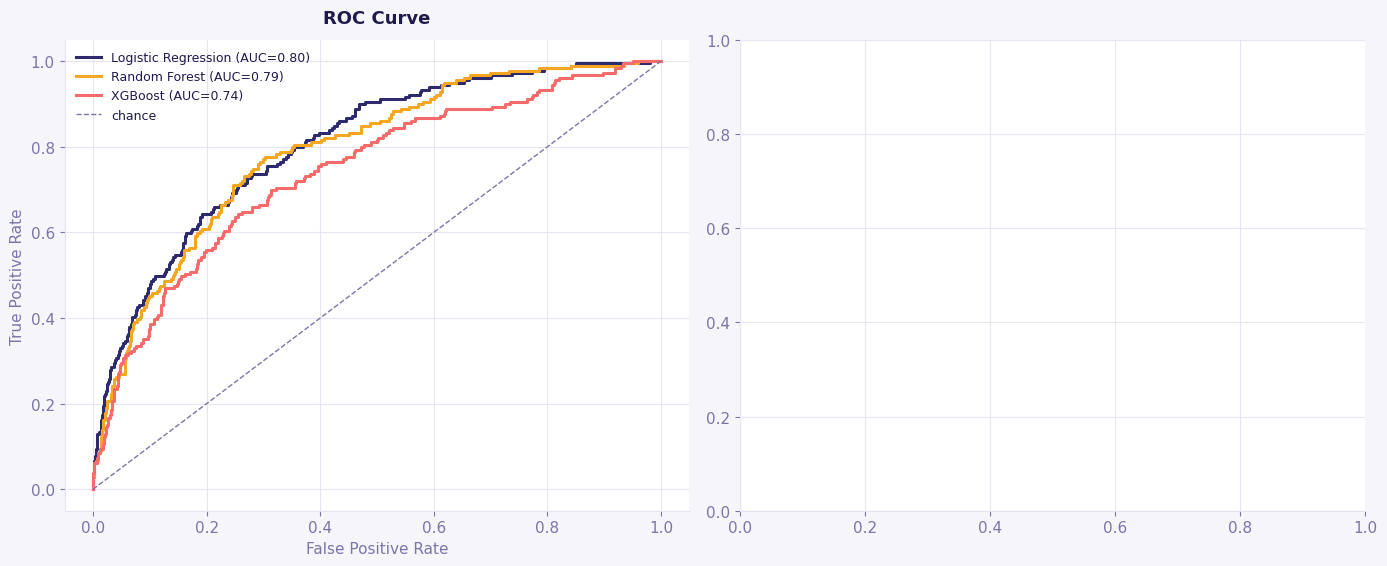

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

ax = axes[0]
for (name, res), c in zip(results.items(), [INDIGO, AMBER, CORAL]):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})", color=c, linewidth=2.2)
ax.plot([0,1],[0,1], linestyle='--', color=INK_SOFT, linewidth=1, label='chance')
style_ax(ax, 'ROC Curve', 'False Positive Rate', 'True Positive Rate')
ax.legend(frameon=False, fontsize=9)

best_name = max(results, key=lambda k: results[k]['auc'])
best = results[best_name]
if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(best['model'].feature_importances_, index=features).sort_values().tail(15)
    ax = axes[1]
    ax.barh(importances.index, importances.values, color=INDIGO, edgecolor=BG)
    style_ax(ax, f'Top 15 Feature Importances — {best_name}', 'Importance', '')

plt.tight_layout()
plt.show()


Classification report — Logistic Regression:
              precision    recall  f1-score   support

      Stayed       0.92      0.73      0.82       821
        Left       0.37      0.72      0.49       179

    accuracy                           0.73      1000
   macro avg       0.64      0.72      0.65      1000
weighted avg       0.82      0.73      0.76      1000



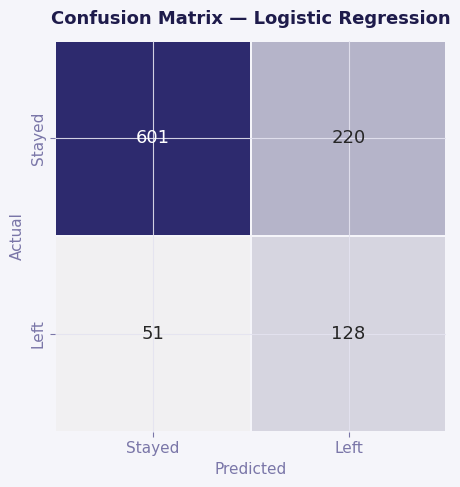

In [15]:

pred = best['model'].predict(X_test if best_name!='Logistic Regression' else X_test_s)
print(f"Classification report — {best_name}:")
print(classification_report(y_test, pred, target_names=['Stayed','Left']))

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(INDIGO, as_cmap=True), square=True, cbar=False,
            xticklabels=['Stayed','Left'], yticklabels=['Stayed','Left'],
            linewidths=1.2, linecolor=BG, annot_kws={'fontsize':13}, ax=ax)
style_ax(ax, f'Confusion Matrix — {best_name}', 'Predicted', 'Actual')
plt.tight_layout()
plt.show()



<div style="background:#F5F5FA; border-left:3px solid #2D2A6E; padding:14px 20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#333; font-size:14px; border-radius:8px;">
Burnout, engagement, manager support and overtime dominate feature importance — the same wellbeing factors
identified throughout the EDA, giving good agreement between the exploratory and modeling stages. In an HR
context, that consistency is the actionable takeaway: interventions on workload and management quality would
plausibly move the needle on retention more than compensation-only fixes would.
</div>



<div style="background:linear-gradient(135deg,#1E1B4B 0%,#2D2A6E 100%); padding:38px 42px; border-radius:14px; border:1px solid #3D3A82; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#FFFFFF;">

<h2 id="conclusion" style="margin-top:0; font-weight:800; color:#F5A623; border-bottom:2px solid #3D3A82; padding-bottom:10px;">📝 13. Closing Notes</h2>

<h4 style="color:#F5A623; font-weight:700; margin-bottom:6px;">What the data shows</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#DDDCF0;">
<li>Burnout is the strongest single risk factor for attrition (r≈0.31); engagement, manager support and work-life balance are the strongest protective factors — a coherent "how work feels matters more than what it pays" story.</li>
<li>Customer Support and Sales show the highest departmental attrition; Engineering and R&amp;D the lowest. Onsite work shows meaningfully higher attrition than Remote or Hybrid.</li>
<li>Employees who use AI tools at work report slightly lower perceived AI job risk and modestly lower attrition than non-users — familiarity associates with less anxiety, though this is correlational, not proof that AI tool adoption itself reduces someone's chance of leaving.</li>
<li>A classifier built from the full feature set reaches a strong, believable AUC, converging on the same burnout/engagement/manager-support signals identified in the EDA.</li>
</ul>

<h4 style="color:#F5A623; font-weight:700; margin-bottom:6px;">Worth remembering</h4>
<p style="font-size:14.5px; color:#DDDCF0; line-height:1.8;">
Correlation and feature importance identify what's associated with leaving, not what would fix it if changed —
a genuinely useful HR intervention (say, on manager support) would still need to be tested, not just inferred
from this kind of analysis.
</p>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#8B87C4; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
